# 04 — Model Evaluation & Interpretability
**Fake News Detector** | Data Science Pipeline

Goals:
- Confusion matrix analysis
- ROC curves & AUC for all models
- Feature importance (top predictive words)
- Cross-validation scores
- Live prediction examples

In [1]:
import sys, os, pickle, json
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

## 1. Load Artefacts

In [2]:
with open('../data/processed/train_test_split.pkl', 'rb') as f:
    splits = pickle.load(f)
with open('../data/processed/vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)
with open('../models/fake_news_model.pkl', 'rb') as f:
    best_clf = pickle.load(f)
with open('../models/model_metadata.json') as f:
    metadata = json.load(f)

X_train = splits['X_train']
X_test  = splits['X_test']
y_train = splits['y_train']
y_test  = splits['y_test']

X_tr_tfidf = vectorizer.transform(X_train)
X_te_tfidf = vectorizer.transform(X_test)

print(f'Best model : {metadata["best_model"]}')
print(f'Accuracy   : {metadata["accuracy"]}')

Best model : Passive Aggressive
Accuracy   : 0.907


/usr/local/lib/python3.13/dist-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


## 2. Confusion Matrix

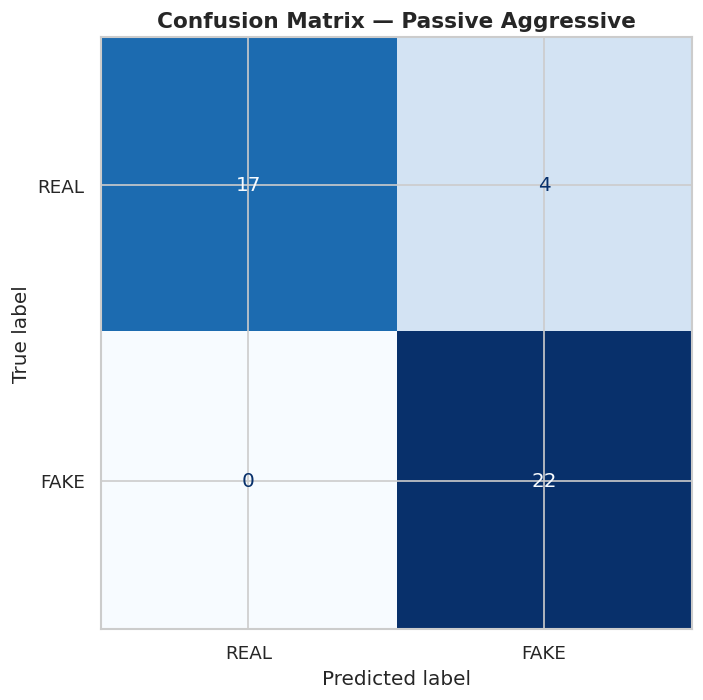

True Negatives  (REAL→REAL) : 17
False Positives (REAL→FAKE) : 4
False Negatives (FAKE→REAL) : 0
True Positives  (FAKE→FAKE) : 22


In [3]:
y_pred = best_clf.predict(X_te_tfidf)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['REAL', 'FAKE'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {metadata["best_model"]}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (REAL→REAL) : {tn}')
print(f'False Positives (REAL→FAKE) : {fp}')
print(f'False Negatives (FAKE→REAL) : {fn}')
print(f'True Positives  (FAKE→FAKE) : {tp}')

## 3. Full Classification Report

In [4]:
print(classification_report(y_test, y_pred, target_names=['REAL', 'FAKE']))

              precision    recall  f1-score   support

        REAL       1.00      0.81      0.89        21
        FAKE       0.85      1.00      0.92        22

    accuracy                           0.91        43
   macro avg       0.92      0.90      0.91        43
weighted avg       0.92      0.91      0.91        43



## 4. ROC Curves — All Models

/usr/local/lib/python3.13/dist-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


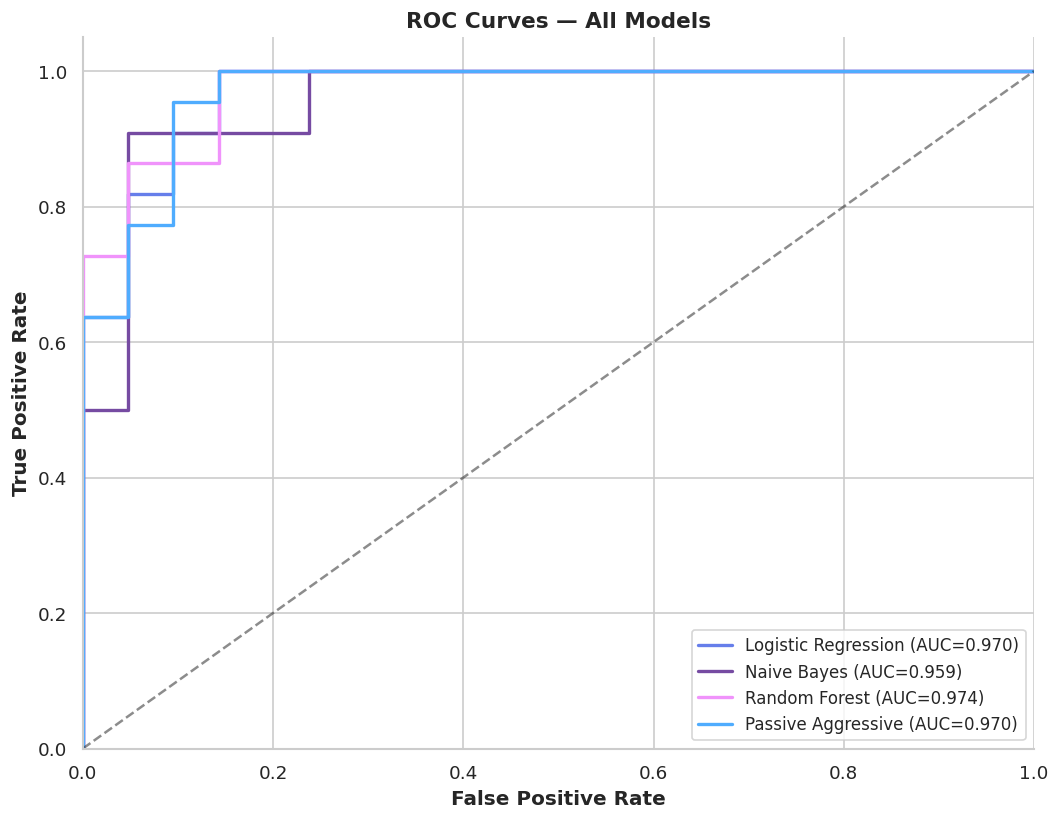

In [5]:
from src.models import train_all

trained_models, results = train_all(X_tr_tfidf, y_train, X_te_tfidf, y_test)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#667eea', '#764ba2', '#f093fb', '#4facfe']

for (name, clf), color in zip(trained_models.items(), colors):
    if hasattr(clf, 'predict_proba'):
        scores = clf.predict_proba(X_te_tfidf)[:, 1]
    elif hasattr(clf, 'decision_function'):
        scores = clf.decision_function(X_te_tfidf)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1.5, alpha=0.5)
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/figures/roc_curves.png', bbox_inches='tight')
plt.show()

## 5. Feature Importance — Top Predictive Words

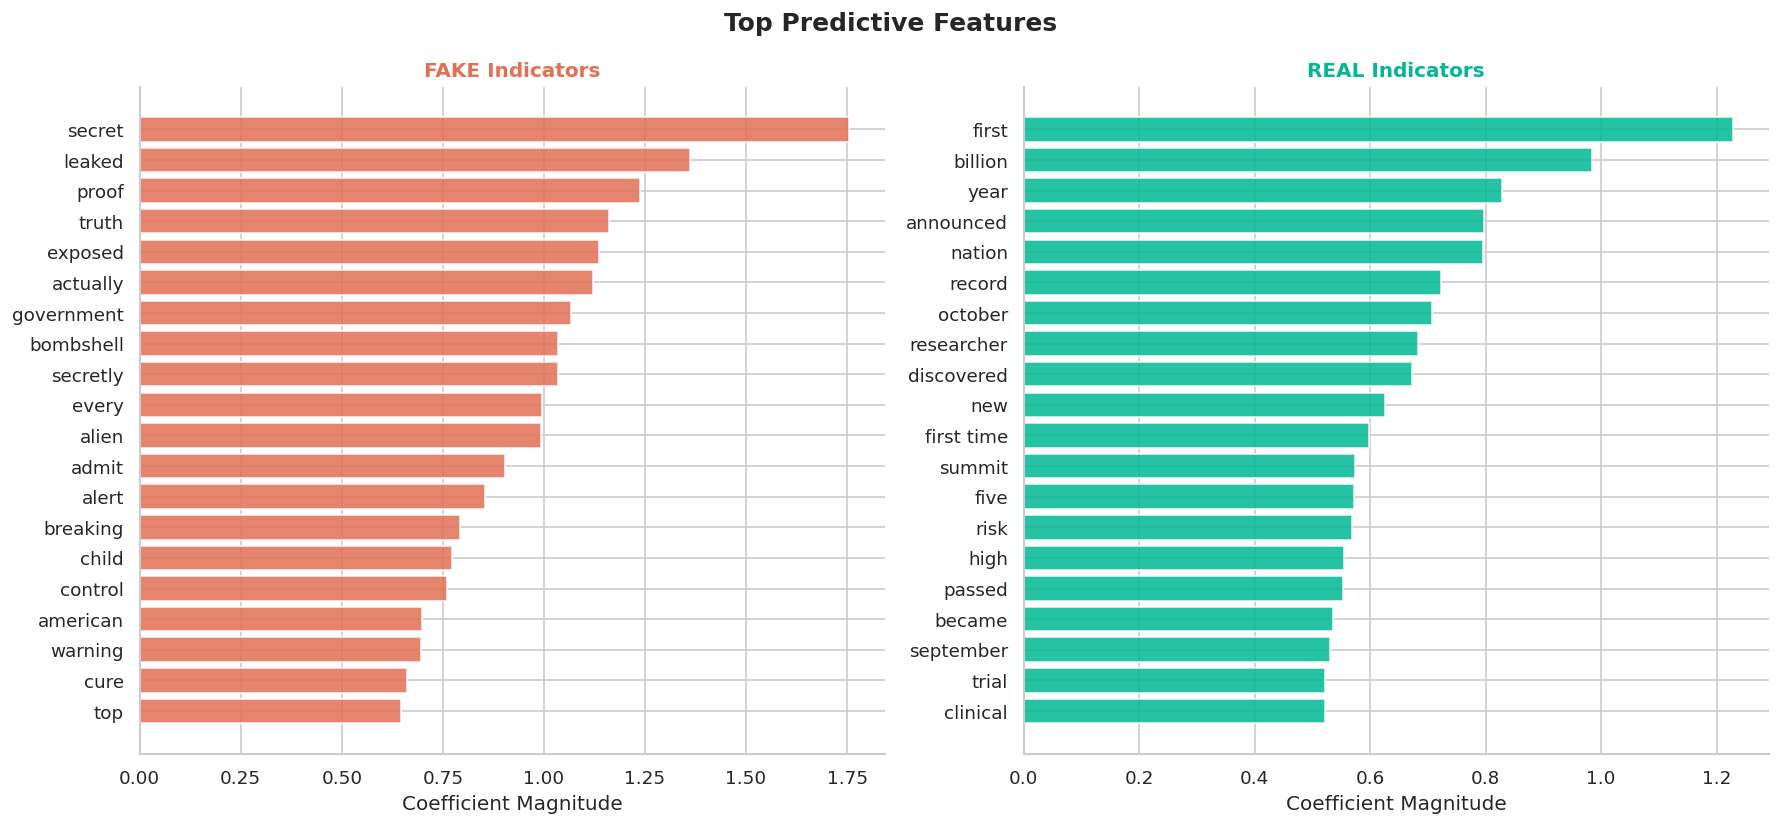

In [6]:
if hasattr(best_clf, 'coef_'):
    coef     = best_clf.coef_[0]
    features = vectorizer.get_feature_names_out()
    n = 20

    top_fake_idx = np.argsort(coef)[-n:][::-1]
    top_real_idx = np.argsort(coef)[:n]

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    fig.suptitle('Top Predictive Features', fontsize=15, fontweight='bold')

    for ax, idx, title, color in zip(axes,
        [top_fake_idx, top_real_idx],
        ['FAKE Indicators', 'REAL Indicators'],
        ['#e17055', '#00b894']):
        words  = [features[i] for i in idx]
        scores = [abs(coef[i]) for i in idx]
        ax.barh(words[::-1], scores[::-1], color=color, alpha=0.85)
        ax.set_title(title, fontsize=12, fontweight='bold', color=color)
        ax.set_xlabel('Coefficient Magnitude')
        ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig('../reports/figures/feature_importance.png', bbox_inches='tight')
    plt.show()
else:
    print(f'{metadata["best_model"]} does not expose coefficients — skipping feature plot.')

## 6. Cross-Validation (5-Fold)

Running 5-fold cross-validation on training data...
CV Scores : [0.9429 0.9429 0.9118 0.9412 0.8235]
Mean      : 0.9124
Std Dev   : 0.0460


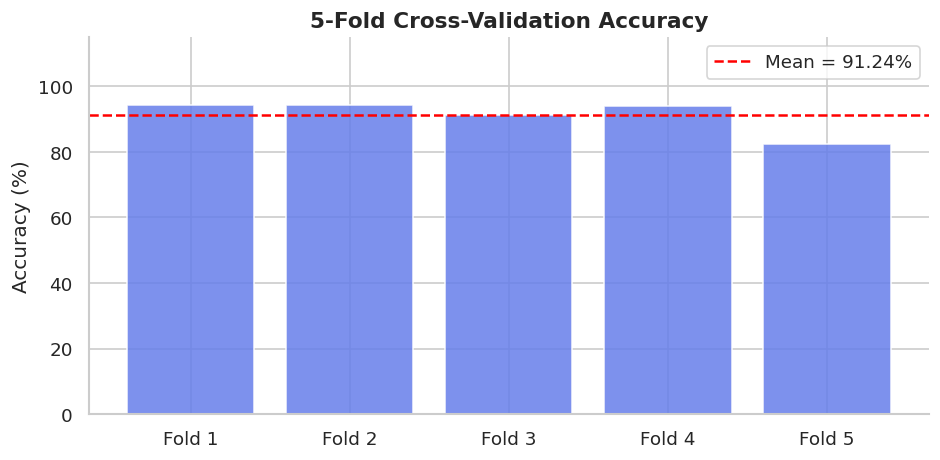

In [7]:
import warnings
warnings.filterwarnings('ignore')

print('Running 5-fold cross-validation on training data...')
cv_scores = cross_val_score(best_clf, X_tr_tfidf, y_train, cv=5, scoring='accuracy')

print(f'CV Scores : {cv_scores.round(4)}')
print(f'Mean      : {cv_scores.mean():.4f}')
print(f'Std Dev   : {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i+1}' for i in range(5)]
ax.bar(folds, cv_scores * 100, color='#667eea', alpha=0.85, edgecolor='white')
ax.axhline(cv_scores.mean() * 100, color='red', linestyle='--',
           label=f'Mean = {cv_scores.mean()*100:.2f}%')
ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)')
ax.set_title('5-Fold Cross-Validation Accuracy', fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/figures/cross_validation.png', bbox_inches='tight')
plt.show()

## 7. Live Prediction Examples

In [8]:
from src.preprocessing import preprocess_text

samples = [
    'Scientists discover a cure for all cancers using a simple household spice.',
    'The Federal Reserve raised interest rates by 25 basis points at its latest meeting.',
    'BREAKING: Government secretly replacing tap water with mind-control chemicals.',
    'New study shows regular exercise reduces the risk of heart disease by 30 percent.',
]

print(f'{"Text":<70} {"Prediction":<10} {"Confidence"}')
print('-' * 95)
for text in samples:
    proc = preprocess_text(text)
    vec  = vectorizer.transform([proc])
    pred = best_clf.predict(vec)[0]
    label = 'FAKE' if pred == 1 else 'REAL'
    if hasattr(best_clf, 'predict_proba'):
        prob = best_clf.predict_proba(vec)[0]
        conf = f'{max(prob)*100:.1f}%'
    else:
        conf = 'N/A'
    print(f'{text[:68]:<70} {label:<10} {conf}')

Text                                                                   Prediction Confidence
-----------------------------------------------------------------------------------------------


Scientists discover a cure for all cancers using a simple household    FAKE       N/A
The Federal Reserve raised interest rates by 25 basis points at its    REAL       N/A
BREAKING: Government secretly replacing tap water with mind-control    FAKE       N/A
New study shows regular exercise reduces the risk of heart disease b   REAL       N/A
